# Graph Neural Network Training and Embedding Analysis

Notebook version of the uploaded Python script. Run the setup and definition cells first, then configure the paths and hyperparameters before training.

In [135]:
import copy
import json
import os
import pickle
import numpy as np
from sklearn import metrics
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import silhouette_score, davies_bouldin_score
from src.dataset import Dataset
from src.model import GCNModel,GATModel
from dgl.dataloading import GraphDataLoader
from tqdm import tqdm
import pandas as pd
import torch
import torch.nn as nn
from src.utils import create_graphs
from src.plot import (populate_miRNA_dic, 
                    populate_disease_dic, 
                    create_heatmap, 
                    miRNA_plot_cosine_similarity_matrix_for_clusters_with_values, 
                    disease_plot_cosine_similarity_matrix_for_clusters_with_values,
                    visualize_embeddings_tsne,visualize_embeddings_pca,
                    calculate_cluster_labels,draw_loss_plot,
                    draw_accuracy_plot,draw_f1_plot)


## FocalLoss

In [136]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        # Ensure the input and target have the same shape
        if inputs.dim() > targets.dim():
            inputs = inputs.squeeze(dim=-1)
        elif targets.dim() > inputs.dim():
            targets = targets.squeeze(dim=-1)

        # Check if the shapes match after squeezing
        if inputs.size() != targets.size():
            raise ValueError(f"Target size ({targets.size()}) must be the same as input size ({inputs.size()})")

        BCE_loss = nn.functional.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-BCE_loss)
        F_loss = self.alpha * (1 - pt) ** self.gamma * BCE_loss

        if self.reduction == 'mean':
            return F_loss.mean()
        elif self.reduction == 'sum':
            return F_loss.sum()
        else:
            return F_loss


## `save_embeddings_to_json()`

In [137]:
def save_embeddings_to_json(file_path, miRNA_data, disease_data):
    data = []
    for name, embedding in miRNA_data:
        data.append({
            "miRNA": {
                "properties": {
                    "name": name,
                    "embedding": embedding.tolist()
                }
            },
            "relation": {
                "type": "ASSOCIATED_WITH"
            },
            "disease": {
                "properties": {
                    "name": "",
                    "embedding": []
                }
            }
        })

    for name, embedding in disease_data:
        data.append({
            "miRNA": {
                "properties": {
                    "name": "",
                    "embedding": []
                }
            },
            "relation": {
                "type": "ASSOCIATED_WITH"
            },
            "disease": {
                "properties": {
                    "name": name,
                    "embedding": embedding.tolist()
                }
            }
        })

    with open(file_path, 'w') as f:
        json.dump(data, f, indent=2)


## Leakage review and safeguards

The training function uses `ds[1]` for training and `ds[0]` for validation. The `Dataset` implementation and graph-construction code are not included here, so graph/node/edge overlap between these partitions cannot be conclusively audited from this notebook alone. Verify that the split is made before any label-informed preprocessing, feature selection, normalization, or graph construction, and that validation/test labels are not used to build training features or edges.

This revision removes the `significance` target field from a cloned graph before each model forward pass, while retaining a detached copy for loss and metrics. This prevents direct leakage if the model could otherwise read that field. It does not prevent indirect leakage through features, edges, node embeddings, or preprocessing that were already constructed using held-out labels. Use a separate untouched test split for final reporting; validation metrics are used for checkpoint selection and are not an unbiased final performance estimate.


In [138]:
def train_ori(hyperparams=None, data_path='data/emb', plot=True):
    num_epochs = hyperparams['num_epochs']
    feat_drop = hyperparams['feat_drop']
    in_feats = hyperparams['in_feats']
    out_feats = hyperparams['out_feats']
    num_layers = hyperparams['num_layers']
    num_heads = hyperparams['num_heads']
    learning_rate = hyperparams['lr']
    batch_size = hyperparams['batch_size']
    device = hyperparams['device']
    num_clusters = hyperparams['num_clusters']
    
    model_path = os.path.join(data_path, 'models')
    model_path = os.path.join(model_path, f'model_dim{out_feats}_lay{num_layers}_epo{num_epochs}.pth')
    
    ds = Dataset(data_path)

    ds_train = [ds[1]]
    ds_valid = [ds[0]]

    ## convert to dgl graph
    dl_train = GraphDataLoader(ds_train, batch_size=batch_size, shuffle=True)
    dl_valid = GraphDataLoader(ds_valid, batch_size=batch_size, shuffle=False)

    '''net = GATModel(in_feats=in_feats, out_feats=out_feats, num_layers=num_layers, num_heads=num_heads, do_train=True).to(device)
    optimizer = optim.Adam(net.parameters(), lr=learning_rate)

    best_model = GATModel(in_feats=in_feats, out_feats=out_feats, num_layers=num_layers, num_heads=num_heads, do_train=True)
    best_model.load_state_dict(copy.deepcopy(net.state_dict()))'''
    
    net = GCNModel(out_feats, num_layers, do_train=True).to(device)
    optimizer = optim.Adam(net.parameters(), lr=learning_rate)

    best_model = GCNModel(out_feats, num_layers, do_train=True)
    best_model.load_state_dict(copy.deepcopy(net.state_dict()))

    loss_per_epoch_train, loss_per_epoch_valid = [], []
    f1_per_epoch_train, f1_per_epoch_valid = [], []

    criterion = FocalLoss(alpha=0.25, gamma=2.0, reduction='mean')
    ##criterion = nn.BCEWithLogitsLoss(reduction='none')
    
    weight = torch.tensor([0.00001, 0.99999]).to(device)

    best_train_loss, best_valid_loss = float('inf'), float('inf')
    best_f1_score = 0.0

    max_f1_scores_train = []
    max_f1_scores_valid = []
    
    results_path = 'results/node_embeddings/'
    os.makedirs(results_path, exist_ok=True)
    
    ##all_miRNA_embeddings, miRNA_cluster_labels, miRNA_names, all_disease_embeddings, disease_cluster_labels, disease_names = (net, dl_train, device, 4)
    all_embeddings_initial_miRNA, cluster_labels_initial_miRNA, graph_name_initial_miRNA, all_embeddings_initial_disease, cluster_labels_initial_disease, graph_name_initial_disease = calculate_cluster_labels(best_model, dl_train, device)

    ##all_embeddings_initial_miRNA, cluster_labels_initial_miRNA, graph_name_initial_miRNA = calculate_cluster_labels_miRNA(best_model, dl_train, device)
    ##print('cluster_labels_initial--------------------------\n',cluster_labels_initial)
    all_embeddings_initial_miRNA = all_embeddings_initial_miRNA.reshape(all_embeddings_initial_miRNA.shape[0], -1)  # Flatten 
    save_path_heatmap_initial_miRNA = os.path.join(results_path, f'heatmap_miRNA_dim{out_feats}_lay{num_layers}_epo{num_epochs}_initial.png')
    save_path_matrix_initial_miRNA = os.path.join(results_path, f'matrix_miRNA_dim{out_feats}_lay{num_layers}_epo{num_epochs}_initial.png')
    save_path_pca_initial_miRNA = os.path.join(results_path, f'pca_miRNA_dim{out_feats}_lay{num_layers}_epo{num_epochs}_initial.png')
    save_path_t_SNE_initial_miRNA = os.path.join(results_path, f't-SNE_miRNA_dim{out_feats}_lay{num_layers}_epo{num_epochs}_initial.png')

    ##all_embeddings_initial_disease, cluster_labels_initial_disease, graph_name_initial_disease = calculate_cluster_labels_disease(best_model, dl_train, device)
    ##print('cluster_labels_initial--------------------------\n',cluster_labels_initial)
    all_embeddings_initial_disease = all_embeddings_initial_disease.reshape(all_embeddings_initial_disease.shape[0], -1)  # Flatten 
    save_path_heatmap_initial_disease = os.path.join(results_path, f'heatmap_disease_dim{out_feats}_lay{num_layers}_epo{num_epochs}_initial.png')
    save_path_matrix_initial_disease = os.path.join(results_path, f'matrix_disease_dim{out_feats}_lay{num_layers}_epo{num_epochs}_initial.png')
    save_path_pca_initial_disease = os.path.join(results_path, f'pca_disease_dim{out_feats}_lay{num_layers}_epo{num_epochs}_initial.png')
    save_path_t_SNE_initial_disease = os.path.join(results_path, f't-SNE_disease_dim{out_feats}_lay{num_layers}_epo{num_epochs}_initial.png')
                
    for data in dl_train:
        graph, _ = data
        # Get all node embeddings from the graph
        node_embeddings_initial = best_model.get_node_embeddings(graph).detach().cpu().numpy()

        # Extract the 'node_type' attribute from the graph
        node_types = graph.ndata['node_type'].cpu().numpy()
        # Create a mask for miRNA nodes (assuming 'miRNA' is represented as a string in node_type)
        miRNA_mask = (node_types == 0)

        # Filter the embeddings using the miRNA mask
        miRNA_node_embeddings = node_embeddings_initial[miRNA_mask]
        disease_mask = (node_types == 1)

        # Filter the embeddings using the disease mask
        disease_node_embeddings = node_embeddings_initial[disease_mask]
                
        ##graph_path = os.path.join(data_path, f'raw/{graph_name_initial_miRNA}.pkl')
        graph_path = os.path.join(data_path, 'raw/emb_train.pkl')
        nx_graph = pickle.load(open(graph_path, 'rb'))
        
        # Filter and get all miRNA nodes
        miRNA_nodes = [node for node in nx_graph.nodes if nx_graph.nodes[node].get('node_type') == 'miRNA']
        print('cluster_labels_miRNA=====================\n',len(cluster_labels_initial_miRNA) )
        print('len(miRNA_nodes)=====================\n',len(miRNA_nodes))
        ##assert len(cluster_labels_initial_miRNA) == len(miRNA_nodes)+139, "Cluster labels and number of nodes must match"
        node_to_index_initial_miRNA = {node: idx for idx, node in enumerate(miRNA_nodes)}

        disease_nodes = [node for node in nx_graph.nodes if nx_graph.nodes[node].get('node_type') == 'disease']

        print('cluster_labels_disease=====================\n',len(cluster_labels_initial_disease))
        print('len(disease_nodes)=====================\n',len(disease_nodes))    
        ##assert len(cluster_labels_initial_disease) == len(disease_nodes)+3, "Cluster labels and number of nodes must match"
        node_to_index_initial_disease = {node: idx for idx, node in enumerate(disease_nodes)}
                
        miRNA_dic_initial, first_node_miRNA_in_cluster_initial, first_node_embedding_in_cluster_initial_miRNA = populate_miRNA_dic(nx_graph, miRNA_node_embeddings, node_to_index_initial_miRNA, cluster_labels_initial_miRNA)
        disease_dic_initial, first_node_disease_in_cluster_initial, first_node_embedding_in_cluster_initial_disease = populate_disease_dic(nx_graph, disease_node_embeddings, node_to_index_initial_disease, cluster_labels_initial_disease)

        ##print('first_node_miRNA_in_cluster_initial-------------------------------\n', first_node_miRNA_in_cluster_initial)
        miRNA_list_initial = list(first_node_miRNA_in_cluster_initial.values())
        miRNA_embedding_list_initial = list(first_node_embedding_in_cluster_initial_miRNA.values())
        
        disease_list_initial = list(first_node_disease_in_cluster_initial.values())
        disease_embedding_list_initial = list(first_node_embedding_in_cluster_initial_disease.values())

        disease_plot_cosine_similarity_matrix_for_clusters_with_values(disease_embedding_list_initial, disease_list_initial, save_path_matrix_initial_disease)
        miRNA_plot_cosine_similarity_matrix_for_clusters_with_values(miRNA_embedding_list_initial, miRNA_list_initial, save_path_matrix_initial_miRNA)
        
        create_heatmap(disease_embedding_list_initial, disease_list_initial, save_path_heatmap_initial_disease)
        create_heatmap(miRNA_embedding_list_initial, miRNA_list_initial, save_path_heatmap_initial_miRNA)

        
        break

    visualize_embeddings_tsne(all_embeddings_initial_miRNA, cluster_labels_initial_miRNA, miRNA_list_initial, save_path_t_SNE_initial_miRNA)
    visualize_embeddings_pca(all_embeddings_initial_miRNA, cluster_labels_initial_miRNA, miRNA_list_initial, save_path_pca_initial_miRNA)
    silhouette_avg_ = silhouette_score(all_embeddings_initial_miRNA, cluster_labels_initial_miRNA)
    davies_bouldin_ = davies_bouldin_score(all_embeddings_initial_miRNA, cluster_labels_initial_miRNA)
    summary_  = f"Silhouette Score: {silhouette_avg_}\n"
    summary_ += f"Davies-Bouldin Index: {davies_bouldin_}\n"

    save_file_= os.path.join(results_path, f'miRNA_head{num_heads}_dim{out_feats}_lay{num_layers}_epo{num_epochs}_initial.txt')
    with open(save_file_, 'w') as f:
        f.write(summary_)


    visualize_embeddings_tsne(all_embeddings_initial_disease, cluster_labels_initial_disease, disease_list_initial, save_path_t_SNE_initial_disease)
    visualize_embeddings_pca(all_embeddings_initial_disease, cluster_labels_initial_disease, disease_list_initial, save_path_pca_initial_disease)
    silhouette_avg_ = silhouette_score(all_embeddings_initial_disease, cluster_labels_initial_disease)
    davies_bouldin_ = davies_bouldin_score(all_embeddings_initial_disease, cluster_labels_initial_disease)
    summary_  = f"Silhouette Score: {silhouette_avg_}\n"
    summary_ += f"Davies-Bouldin Index: {davies_bouldin_}\n"

    save_file_= os.path.join(results_path, f'disease_head{num_heads}_dim{out_feats}_lay{num_layers}_epo{num_epochs}_initial.txt')
    with open(save_file_, 'w') as f:
        f.write(summary_)    
            
    loss_per_epoch_train, loss_per_epoch_valid = [], []
    f1_per_epoch_train, f1_per_epoch_valid = [], []    
    accuracy_per_epoch_train, accuracy_per_epoch_valid = [], []
    
    # Start training  
    with tqdm(total=num_epochs, desc="Training", unit="epoch", leave=False) as pbar:
        for epoch in range(num_epochs):
            loss_per_graph = []
            f1_per_graph = []
            accuracy_per_graph = []
            net.train()
            for data in dl_train:
                graph, name = data
                name = name[0]
                # Keep target labels separate from model inputs to prevent direct label leakage.
                labels = graph.ndata['significance'].detach().clone().unsqueeze(-1)
                graph_input = graph.clone()
                del graph_input.ndata['significance']
                logits = net(graph_input)
                weight_ = weight[labels.data.view(-1).long()].view_as(labels)

                loss = criterion(logits, labels)
                loss_weighted = loss * weight_
                loss_weighted = loss_weighted.mean()

                # Update parameters
                optimizer.zero_grad()
                loss_weighted.backward()
                optimizer.step()
                
                # Append output metrics
                loss_per_graph.append(loss_weighted.item())
                preds = (logits.sigmoid() > 0.5).int()
                labels = labels.squeeze(1).int()
                f1 = metrics.f1_score(labels, preds)
                accuracy = metrics.accuracy_score(labels, preds)
                f1_per_graph.append(f1)
                accuracy_per_graph.append(accuracy)

            running_loss = np.array(loss_per_graph).mean()
            running_f1 = np.array(f1_per_graph).mean()
            running_accuracy = np.array(accuracy_per_graph).mean()
            loss_per_epoch_train.append(running_loss)
            f1_per_epoch_train.append(running_f1)
            accuracy_per_epoch_train.append(running_accuracy)

            # Validation iteration
            with torch.no_grad():
                loss_per_graph = []
                f1_per_graph_val = []
                accuracy_per_graph_val = []
                net.eval()
                for data in dl_valid:
                    graph, name = data
                    name = name[0]
                    # Validation targets are used only for loss/metrics, never as model inputs.
                    labels = graph.ndata['significance'].detach().clone().unsqueeze(-1)
                    graph_input = graph.clone()
                    del graph_input.ndata['significance']
                    logits = net(graph_input)
                    weight_ = weight[labels.data.view(-1).long()].view_as(labels)
                    loss = criterion(logits, labels)
                    loss_weighted = loss * weight_
                    loss_weighted = loss_weighted.mean()
                    loss_per_graph.append(loss_weighted.item())
                    preds = (logits.sigmoid() > 0.5).int()
                    labels = labels.squeeze(1).int()
                    f1 = metrics.f1_score(labels, preds)
                    accuracy = metrics.accuracy_score(labels, preds)
                    f1_per_graph_val.append(f1)
                    accuracy_per_graph_val.append(accuracy)

                running_loss = np.array(loss_per_graph).mean()
                running_f1_val = np.array(f1_per_graph_val).mean()
                running_accuracy_val = np.array(accuracy_per_graph_val).mean()
                loss_per_epoch_valid.append(running_loss)
                f1_per_epoch_valid.append(running_f1_val)
                accuracy_per_epoch_valid.append(running_accuracy_val)

                max_f1_train = max(f1_per_epoch_train)
                max_f1_valid = max(f1_per_epoch_valid)
                max_f1_scores_train.append(max_f1_train)
                max_f1_scores_valid.append(max_f1_valid)
                
                if running_loss < best_valid_loss:
                    best_train_loss = loss_per_epoch_train[-1]
                    best_valid_loss = running_loss
                    best_f1_score = running_f1_val
                    best_model.load_state_dict(copy.deepcopy(net.state_dict()))
                    print(f"Best F1 Score: {best_f1_score}")

            pbar.update(1)
            print(f"Epoch {epoch + 1} - F1 Train: {running_f1}, F1 Valid: {running_f1_val}, Accuracy Train: {running_accuracy}, Accuracy Valid: {running_accuracy_val}")

    ##all_embeddings, cluster_labels, miRNA_names, all_disease_embeddings, disease_cluster_labels, disease_names = calculate_cluster_labels(best_model, dl_train, device)
    all_embeddings_miRNA, cluster_labels_miRNA, graph_name_initial_miRNA, all_embeddings_disease, cluster_labels_disease, graph_name_disease = calculate_cluster_labels(best_model, dl_train, device, num_clusters)
    
    all_embeddings_miRNA = all_embeddings_miRNA.reshape(all_embeddings_miRNA.shape[0], -1)  # Flatten 
    save_path_heatmap_miRNA = os.path.join(results_path, f'heatmap_miRNA_dim{out_feats}_lay{num_layers}_epo{num_epochs}.png')
    save_path_matrix_miRNA = os.path.join(results_path, f'matrix_miRNA_dim{out_feats}_lay{num_layers}_epo{num_epochs}.png')
    save_path_pca_miRNA = os.path.join(results_path, f'pca_miRNA_dim{out_feats}_lay{num_layers}_epo{num_epochs}.png')
    save_path_t_SNE_miRNA = os.path.join(results_path, f't-SNE_miRNA_dim{out_feats}_lay{num_layers}_epo{num_epochs}.png')

    ##all_embeddings_disease, cluster_labels_disease, graph_name_disease = calculate_cluster_labels_disease(best_model, dl_train, device)
    ##print('cluster_labels--------------------------\n',cluster_labels)
    all_embeddings_disease = all_embeddings_disease.reshape(all_embeddings_disease.shape[0], -1)  # Flatten 
    save_path_heatmap_disease = os.path.join(results_path, f'heatmap_disease_dim{out_feats}_lay{num_layers}_epo{num_epochs}.png')
    save_path_matrix_disease = os.path.join(results_path, f'matrix_disease_dim{out_feats}_lay{num_layers}_epo{num_epochs}.png')
    save_path_pca_disease = os.path.join(results_path, f'pca_disease_dim{out_feats}_lay{num_layers}_epo{num_epochs}.png')
    save_path_t_SNE_disease = os.path.join(results_path, f't-SNE_disease_dim{out_feats}_lay{num_layers}_epo{num_epochs}_.png')
                
                    
    all_embeddings_miRNA = all_embeddings_miRNA.reshape(all_embeddings_miRNA.shape[0], -1)  # Flatten 
    print('cluster_labels=========================\n', cluster_labels_miRNA)

    cos_sim = np.dot(all_embeddings_miRNA, all_embeddings_miRNA.T)
    norms = np.linalg.norm(all_embeddings_miRNA, axis=1)
    cos_sim /= np.outer(norms, norms)
    
    if plot:
        loss_path = os.path.join(results_path, f'loss_head{num_heads}_dim{out_feats}_lay{num_layers}_epo{num_epochs}.png')
        f1_path = os.path.join(results_path, f'f1_head{num_heads}_dim{out_feats}_lay{num_layers}_epo{num_epochs}.png')
        accuracy_path = os.path.join(results_path, f'accuracy_head{num_heads}_dim{out_feats}_lay{num_layers}_epo{num_epochs}.png')

        draw_loss_plot(loss_per_epoch_train, loss_per_epoch_valid, loss_path)
        draw_f1_plot(f1_per_epoch_train, f1_per_epoch_valid, f1_path)
        draw_accuracy_plot(accuracy_per_epoch_train, accuracy_per_epoch_valid, accuracy_path)

    os.makedirs(os.path.dirname(model_path), exist_ok=True)
    torch.save(best_model.state_dict(), model_path)
            
    torch.save(best_model.state_dict(), model_path)

    for data in dl_train:
        graph, _ = data
        # Get all node embeddings from the graph
        node_embeddings = best_model.get_node_embeddings(graph).detach().cpu().numpy()

        # Extract the 'node_type' attribute from the graph
        node_types = graph.ndata['node_type'].cpu().numpy()
        
        print('node_types=====================\n',node_types)

        # Create a mask for miRNA nodes (assuming 'miRNA' is represented as a string in node_type)
        miRNA_mask = (node_types == 0)

        # Filter the embeddings using the miRNA mask
        miRNA_node_embeddings = node_embeddings[miRNA_mask]

        print(f"Shape of miRNA node embeddings: {miRNA_node_embeddings.shape}")

        disease_mask = (node_types == 1)

        # Filter the embeddings using the disease mask
        disease_node_embeddings = node_embeddings[disease_mask]

        print(f"Shape of disease node embeddings: {disease_node_embeddings.shape}")
                
        ##graph_path = os.path.join(data_path, f'raw/{graph_name_miRNA}.pkl')
        graph_path = os.path.join(data_path, 'raw/emb_train.pkl')
        nx_graph = pickle.load(open(graph_path, 'rb'))
        
        # Filter and get all miRNA nodes
        miRNA_nodes = [node for node in nx_graph.nodes if nx_graph.nodes[node].get('node_type') == 'miRNA']
    
        print('cluster_labels_miRNA=====================\n',len(cluster_labels_miRNA))
        print('len(miRNA_nodes)=====================\n',len(miRNA_nodes))

        ##assert len(cluster_labels_miRNA) == len(miRNA_nodes)+139, "Cluster labels and number of nodes must match"
        node_to_index_miRNA = {node: idx for idx, node in enumerate(miRNA_nodes)}

        disease_nodes = [node for node in nx_graph.nodes if nx_graph.nodes[node].get('node_type') == 'disease']

        print('cluster_labels_disease=====================\n',len(cluster_labels_disease))
        print('len(disease_nodes)=====================\n',len(disease_nodes))
               
        ##assert len(cluster_labels_disease) == len(disease_nodes)+3, "Cluster labels and number of nodes must match"
        node_to_index_disease = {node: idx for idx, node in enumerate(disease_nodes)}
                
        miRNA_dic, first_node_miRNA_in_cluster, first_node_embedding_in_cluster_miRNA = populate_miRNA_dic(nx_graph, miRNA_node_embeddings, node_to_index_miRNA, cluster_labels_miRNA)
        disease_dic, first_node_disease_in_cluster, first_node_embedding_in_cluster_disease = populate_disease_dic(nx_graph, disease_node_embeddings, node_to_index_disease, cluster_labels_disease)

        print('first_node_miRNA_in_cluster=====================\n',first_node_miRNA_in_cluster)
        print('first_node_disease_in_cluster=====================\n',first_node_disease_in_cluster)
                
        ##print('first_node_miRNA_in_cluster-------------------------------\n', first_node_miRNA_in_cluster)
        miRNA_list = list(first_node_miRNA_in_cluster.values())
        miRNA_embedding_list = list(first_node_embedding_in_cluster_miRNA.values())
        
        ##print('miRNA_embedding_list=====================\n',miRNA_embedding_list)
        print('miRNA_list=====================\n',miRNA_list)

        disease_list = list(first_node_disease_in_cluster.values())
        disease_embedding_list = list(first_node_embedding_in_cluster_disease.values())

        ##print('disease_embedding_list=====================\n',disease_embedding_list)
        print('disease_list=====================\n',disease_list)

        
        

        disease_plot_cosine_similarity_matrix_for_clusters_with_values(disease_embedding_list, disease_list, save_path_matrix_disease)
        miRNA_plot_cosine_similarity_matrix_for_clusters_with_values(miRNA_embedding_list, miRNA_list, save_path_matrix_miRNA)
        
        create_heatmap(disease_embedding_list, disease_list, save_path_heatmap_disease)
        create_heatmap(miRNA_embedding_list, miRNA_list, save_path_heatmap_miRNA)

        
        break

    visualize_embeddings_tsne(all_embeddings_miRNA, cluster_labels_miRNA, miRNA_list, save_path_t_SNE_miRNA)
    visualize_embeddings_pca(all_embeddings_miRNA, cluster_labels_miRNA, miRNA_list, save_path_pca_miRNA)
    silhouette_avg_miRNA = silhouette_score(all_embeddings_miRNA, cluster_labels_miRNA)
    davies_bouldin_miRNA = davies_bouldin_score(all_embeddings_miRNA, cluster_labels_miRNA)
    summary_  = f"Silhouette Score: {silhouette_avg_miRNA}\n"
    summary_ += f"Davies-Bouldin Index: {davies_bouldin_miRNA}\n"

    save_file_= os.path.join(results_path, f'miRNA_head{num_heads}_dim{out_feats}_lay{num_layers}_epo{num_epochs}.txt')
    with open(save_file_, 'w') as f:
        f.write(summary_)


    visualize_embeddings_tsne(all_embeddings_disease, cluster_labels_disease, disease_list, save_path_t_SNE_disease)
    visualize_embeddings_pca(all_embeddings_disease, cluster_labels_disease, disease_list, save_path_pca_disease)
    silhouette_avg_disease = silhouette_score(all_embeddings_disease, cluster_labels_disease)
    davies_bouldin_disease = davies_bouldin_score(all_embeddings_disease, cluster_labels_disease)
    summary_  = f"Silhouette Score: {silhouette_avg_}\n"
    summary_ += f"Davies-Bouldin Index: {davies_bouldin_}\n"

    save_file_= os.path.join(results_path, f'disease_head{num_heads}_dim{out_feats}_lay{num_layers}_epo{num_epochs}.txt')
    with open(save_file_, 'w') as f:
        f.write(summary_)    

    print(f"Silhouette Score%%%%%%%%%%%%###########################: {silhouette_avg_disease}")
    print(f"Davies-Bouldin Index: {davies_bouldin_disease}")

    summary = f"Epoch {num_epochs} - Max F1 Train: {max_f1_train}, Max F1 Valid: {max_f1_valid}\n"
    summary += f"Best Train Loss: {best_train_loss}\n"
    summary += f"Best Validation Loss: {best_valid_loss}\n"
    summary += f"Best F1 Score: {max_f1_train}\n"
    summary += f"Silhouette Score: {silhouette_avg_disease}\n"
    summary += f"Davies-Bouldin Index: {davies_bouldin_disease}\n"

    save_file = os.path.join(results_path, f'head{num_heads}_lr{learning_rate}_dim{out_feats}_lay{num_layers}_epo{num_epochs}.txt')
    with open(save_file, 'w') as f:
        f.write(summary)


    ## save_to_neo4j(graph_train, miRNA_dic, miRNA_mapping, pathway_map, gene_id_to_name_mapping, gene_id_to_symbol_mapping, neo4j_uri, neo4j_user, neo4j_password)
    
    miRNA_embeddings_initial = pd.DataFrame.from_dict(miRNA_dic_initial, orient='index')
    miRNA_embeddings_initial.to_csv('data/miRNA_embeddings_initial.csv', index_label='miRNA')

    miRNA_embeddings = pd.DataFrame.from_dict(miRNA_dic, orient='index')
    miRNA_embeddings.to_csv('data/pretrain_miRNA_embeddings.csv', index_label='miRNA')
    
    disease_embeddings_initial = pd.DataFrame.from_dict(disease_dic_initial, orient='index')
    disease_embeddings_initial.to_csv('data/disease_embeddings_initial.csv', index_label='disease')

    disease_embeddings = pd.DataFrame.from_dict(disease_dic, orient='index')
    disease_embeddings.to_csv('data/pretrain_disease_embeddings.csv', index_label='disease')
    
    return model_path

def train(hyperparams=None, data_path='data/emb', plot=True):

    # ============================================================
    # 1. Hyperparameters
    # ============================================================
    num_epochs = hyperparams['num_epochs']
    feat_drop = hyperparams['feat_drop']
    in_feats = hyperparams['in_feats']
    out_feats = hyperparams['out_feats']
    num_layers = hyperparams['num_layers']
    num_heads = hyperparams['num_heads']
    learning_rate = hyperparams['lr']
    batch_size = hyperparams['batch_size']
    device = hyperparams['device']
    num_clusters = hyperparams['num_clusters']

    # ============================================================
    # 2. Paths
    # ============================================================
    model_path = os.path.join(data_path, 'models')
    model_path = os.path.join(
        model_path,
        f'model_dim{out_feats}_lay{num_layers}_epo{num_epochs}.pth'
    )

    results_path = 'results/node_embeddings/'
    os.makedirs(results_path, exist_ok=True)

    # ============================================================
    # 3. Dataset
    # ============================================================
    ds = Dataset(data_path)

    ds_train = [ds[1]]
    ds_valid = [ds[0]]

    dl_train = GraphDataLoader(
        ds_train,
        batch_size=batch_size,
        shuffle=True
    )

    dl_valid = GraphDataLoader(
        ds_valid,
        batch_size=batch_size,
        shuffle=False
    )

    # ============================================================
    # 4. Create model
    # ============================================================
    net = GCNModel(
        out_feats,
        num_layers,
        do_train=True
    ).to(device)

    optimizer = optim.Adam(
        net.parameters(),
        lr=learning_rate
    )

    # ============================================================
    # IMPORTANT:
    # Save an EXACT copy of the untrained model.
    #
    # This is the INITIAL model.
    #
    # Do NOT create another independently initialized model,
    # because that would make the initial representation come
    # from different random weights than the model being trained.
    # ============================================================
    initial_model = copy.deepcopy(net)

    # Best model will be updated during training.
    best_model = copy.deepcopy(net)

    # ============================================================
    # 5. Loss
    # ============================================================
    criterion = FocalLoss(
        alpha=0.25,
        gamma=2.0,
        reduction='mean'
    )

    weight = torch.tensor(
        [0.00001, 0.99999],
        device=device
    )

    # ============================================================
    # 6. Training bookkeeping
    # ============================================================
    loss_per_epoch_train = []
    loss_per_epoch_valid = []

    f1_per_epoch_train = []
    f1_per_epoch_valid = []

    accuracy_per_epoch_train = []
    accuracy_per_epoch_valid = []

    max_f1_scores_train = []
    max_f1_scores_valid = []

    best_train_loss = float('inf')
    best_valid_loss = float('inf')
    best_f1_score = 0.0

    # ============================================================
    # ============================================================
    #
    #                 INITIAL EMBEDDINGS
    #
    # ============================================================
    #
    # These embeddings are generated BEFORE any optimization step.
    #
    # ============================================================
    # 7. Calculate INITIAL embeddings
    # ============================================================
    (
        all_embeddings_initial_miRNA,
        cluster_labels_initial_miRNA,
        graph_name_initial_miRNA,
        all_embeddings_initial_disease,
        cluster_labels_initial_disease,
        graph_name_initial_disease
    ) = calculate_cluster_labels(
        initial_model,
        dl_train,
        device,
        num_clusters
    )

    # ------------------------------------------------------------
    # Flatten embeddings
    # ------------------------------------------------------------
    all_embeddings_initial_miRNA = (
        all_embeddings_initial_miRNA.reshape(
            all_embeddings_initial_miRNA.shape[0],
            -1
        )
    )

    all_embeddings_initial_disease = (
        all_embeddings_initial_disease.reshape(
            all_embeddings_initial_disease.shape[0],
            -1
        )
    )

    # ============================================================
    # 8. INITIAL output paths
    # ============================================================
    save_path_heatmap_initial_miRNA = os.path.join(
        results_path,
        f'heatmap_miRNA_dim{out_feats}_lay{num_layers}_epo{num_epochs}_INITIAL.png'
    )

    save_path_matrix_initial_miRNA = os.path.join(
        results_path,
        f'matrix_miRNA_dim{out_feats}_lay{num_layers}_epo{num_epochs}_INITIAL.png'
    )

    save_path_pca_initial_miRNA = os.path.join(
        results_path,
        f'pca_miRNA_dim{out_feats}_lay{num_layers}_epo{num_epochs}_INITIAL.png'
    )

    save_path_t_SNE_initial_miRNA = os.path.join(
        results_path,
        f't-SNE_miRNA_dim{out_feats}_lay{num_layers}_epo{num_epochs}_INITIAL.png'
    )

    save_path_heatmap_initial_disease = os.path.join(
        results_path,
        f'heatmap_disease_dim{out_feats}_lay{num_layers}_epo{num_epochs}_INITIAL.png'
    )

    save_path_matrix_initial_disease = os.path.join(
        results_path,
        f'matrix_disease_dim{out_feats}_lay{num_layers}_epo{num_epochs}_INITIAL.png'
    )

    save_path_pca_initial_disease = os.path.join(
        results_path,
        f'pca_disease_dim{out_feats}_lay{num_layers}_epo{num_epochs}_INITIAL.png'
    )

    save_path_t_SNE_initial_disease = os.path.join(
        results_path,
        f't-SNE_disease_dim{out_feats}_lay{num_layers}_epo{num_epochs}_INITIAL.png'
    )

    # ============================================================
    # 9. Extract INITIAL node embeddings
    # ============================================================
    for data in dl_train:

        graph, _ = data

        node_embeddings_initial = (
            initial_model
            .get_node_embeddings(graph)
            .detach()
            .cpu()
            .numpy()
        )

        node_types = graph.ndata['node_type'].cpu().numpy()

        # --------------------------------------------------------
        # miRNA
        # --------------------------------------------------------
        miRNA_mask = (node_types == 0)

        miRNA_node_embeddings_initial = (
            node_embeddings_initial[miRNA_mask]
        )

        # --------------------------------------------------------
        # Disease
        # --------------------------------------------------------
        disease_mask = (node_types == 1)

        disease_node_embeddings_initial = (
            node_embeddings_initial[disease_mask]
        )

        # --------------------------------------------------------
        # Load NetworkX graph
        # --------------------------------------------------------
        graph_path = os.path.join(
            data_path,
            'raw/emb_train.pkl'
        )

        nx_graph = pickle.load(
            open(graph_path, 'rb')
        )

        # --------------------------------------------------------
        # miRNA nodes
        # --------------------------------------------------------
        miRNA_nodes = [
            node
            for node in nx_graph.nodes
            if nx_graph.nodes[node].get('node_type') == 'miRNA'
        ]

        print(
            'INITIAL miRNA cluster labels:',
            len(cluster_labels_initial_miRNA)
        )

        print(
            'INITIAL miRNA nodes:',
            len(miRNA_nodes)
        )

        node_to_index_initial_miRNA = {
            node: idx
            for idx, node in enumerate(miRNA_nodes)
        }

        # --------------------------------------------------------
        # Disease nodes
        # --------------------------------------------------------
        disease_nodes = [
            node
            for node in nx_graph.nodes
            if nx_graph.nodes[node].get('node_type') == 'disease'
        ]

        print(
            'INITIAL disease cluster labels:',
            len(cluster_labels_initial_disease)
        )

        print(
            'INITIAL disease nodes:',
            len(disease_nodes)
        )

        node_to_index_initial_disease = {
            node: idx
            for idx, node in enumerate(disease_nodes)
        }

        # --------------------------------------------------------
        # Populate dictionaries
        # --------------------------------------------------------
        (
            miRNA_dic_initial,
            first_node_miRNA_in_cluster_initial,
            first_node_embedding_in_cluster_initial_miRNA
        ) = populate_miRNA_dic(
            nx_graph,
            miRNA_node_embeddings_initial,
            node_to_index_initial_miRNA,
            cluster_labels_initial_miRNA
        )

        (
            disease_dic_initial,
            first_node_disease_in_cluster_initial,
            first_node_embedding_in_cluster_initial_disease
        ) = populate_disease_dic(
            nx_graph,
            disease_node_embeddings_initial,
            node_to_index_initial_disease,
            cluster_labels_initial_disease
        )

        # --------------------------------------------------------
        # First node from each INITIAL cluster
        # --------------------------------------------------------
        miRNA_list_initial = list(
            first_node_miRNA_in_cluster_initial.values()
        )

        miRNA_embedding_list_initial = list(
            first_node_embedding_in_cluster_initial_miRNA.values()
        )

        disease_list_initial = list(
            first_node_disease_in_cluster_initial.values()
        )

        disease_embedding_list_initial = list(
            first_node_embedding_in_cluster_initial_disease.values()
        )

        # --------------------------------------------------------
        # INITIAL cosine matrices
        # --------------------------------------------------------
        disease_plot_cosine_similarity_matrix_for_clusters_with_values(
            disease_embedding_list_initial,
            disease_list_initial,
            save_path_matrix_initial_disease
        )

        miRNA_plot_cosine_similarity_matrix_for_clusters_with_values(
            miRNA_embedding_list_initial,
            miRNA_list_initial,
            save_path_matrix_initial_miRNA
        )

        # --------------------------------------------------------
        # INITIAL heatmaps
        # --------------------------------------------------------
        create_heatmap(
            disease_embedding_list_initial,
            disease_list_initial,
            save_path_heatmap_initial_disease
        )

        create_heatmap(
            miRNA_embedding_list_initial,
            miRNA_list_initial,
            save_path_heatmap_initial_miRNA
        )

        break

    # ============================================================
    # 10. INITIAL PCA / t-SNE
    # ============================================================
    visualize_embeddings_tsne(
        all_embeddings_initial_miRNA,
        cluster_labels_initial_miRNA,
        miRNA_list_initial,
        save_path_t_SNE_initial_miRNA
    )

    visualize_embeddings_pca(
        all_embeddings_initial_miRNA,
        cluster_labels_initial_miRNA,
        miRNA_list_initial,
        save_path_pca_initial_miRNA
    )

    visualize_embeddings_tsne(
        all_embeddings_initial_disease,
        cluster_labels_initial_disease,
        disease_list_initial,
        save_path_t_SNE_initial_disease
    )

    # visualize_embeddings_pca(
    #     all_embeddings_initial_disease,
    #     cluster_labels_initial_disease,
    #     disease_list_initial,
    #     save_path_pca_initial_disease
    # )

    # ============================================================
    # 11. INITIAL clustering metrics
    # ============================================================
    silhouette_initial_miRNA = silhouette_score(
        all_embeddings_initial_miRNA,
        cluster_labels_initial_miRNA
    )

    davies_bouldin_initial_miRNA = davies_bouldin_score(
        all_embeddings_initial_miRNA,
        cluster_labels_initial_miRNA
    )

    silhouette_initial_disease = silhouette_score(
        all_embeddings_initial_disease,
        cluster_labels_initial_disease
    )

    davies_bouldin_initial_disease = davies_bouldin_score(
        all_embeddings_initial_disease,
        cluster_labels_initial_disease
    )

    print("\n" + "=" * 70)
    print("INITIAL EMBEDDING RESULTS")
    print("=" * 70)

    print(
        f"Initial miRNA Silhouette Score: "
        f"{silhouette_initial_miRNA}"
    )

    print(
        f"Initial miRNA Davies-Bouldin Index: "
        f"{davies_bouldin_initial_miRNA}"
    )

    print(
        f"Initial disease Silhouette Score: "
        f"{silhouette_initial_disease}"
    )

    print(
        f"Initial disease Davies-Bouldin Index: "
        f"{davies_bouldin_initial_disease}"
    )

    print("=" * 70 + "\n")

    # ============================================================
    # 12. Save INITIAL metric files
    # ============================================================
    initial_miRNA_summary = (
        f"Embedding Stage: INITIAL\n"
        f"Training Status: Before Training\n"
        f"Silhouette Score: {silhouette_initial_miRNA}\n"
        f"Davies-Bouldin Index: {davies_bouldin_initial_miRNA}\n"
    )

    initial_disease_summary = (
        f"Embedding Stage: INITIAL\n"
        f"Training Status: Before Training\n"
        f"Silhouette Score: {silhouette_initial_disease}\n"
        f"Davies-Bouldin Index: {davies_bouldin_initial_disease}\n"
    )

    initial_miRNA_file = os.path.join(
        results_path,
        f'miRNA_head{num_heads}_dim{out_feats}_lay{num_layers}_epo{num_epochs}_INITIAL.txt'
    )

    initial_disease_file = os.path.join(
        results_path,
        f'disease_head{num_heads}_dim{out_feats}_lay{num_layers}_epo{num_epochs}_INITIAL.txt'
    )

    with open(initial_miRNA_file, 'w') as f:
        f.write(initial_miRNA_summary)

    with open(initial_disease_file, 'w') as f:
        f.write(initial_disease_summary)

    # ============================================================
    # ============================================================
    #
    #                         TRAINING
    #
    # ============================================================
    # ============================================================

    with tqdm(
        total=num_epochs,
        desc="Training",
        unit="epoch",
        leave=False
    ) as pbar:

        for epoch in range(num_epochs):

            # ----------------------------------------------------
            # Training
            # ----------------------------------------------------
            loss_per_graph = []
            f1_per_graph = []
            accuracy_per_graph = []

            net.train()

            for data in dl_train:

                graph, name = data
                name = name[0]

                # Keep labels separate from model inputs
                labels = (
                    graph.ndata['significance']
                    .detach()
                    .clone()
                    .unsqueeze(-1)
                )

                graph_input = graph.clone()

                del graph_input.ndata['significance']

                logits = net(graph_input)

                weight_ = (
                    weight[
                        labels.data.view(-1).long()
                    ].view_as(labels)
                )

                loss = criterion(
                    logits,
                    labels
                )

                loss_weighted = loss * weight_
                loss_weighted = loss_weighted.mean()

                optimizer.zero_grad()

                loss_weighted.backward()

                optimizer.step()

                # ------------------------------------------------
                # Metrics
                # ------------------------------------------------
                loss_per_graph.append(
                    loss_weighted.item()
                )

                preds = (
                    logits.sigmoid() > 0.5
                ).int()

                labels_metric = (
                    labels.squeeze(1).int()
                )

                f1 = metrics.f1_score(
                    labels_metric,
                    preds
                )

                accuracy = metrics.accuracy_score(
                    labels_metric,
                    preds
                )

                f1_per_graph.append(f1)
                accuracy_per_graph.append(accuracy)

            # ----------------------------------------------------
            # Epoch training metrics
            # ----------------------------------------------------
            running_loss = np.array(
                loss_per_graph
            ).mean()

            running_f1 = np.array(
                f1_per_graph
            ).mean()

            running_accuracy = np.array(
                accuracy_per_graph
            ).mean()

            loss_per_epoch_train.append(
                running_loss
            )

            f1_per_epoch_train.append(
                running_f1
            )

            accuracy_per_epoch_train.append(
                running_accuracy
            )

            # ----------------------------------------------------
            # Validation
            # ----------------------------------------------------
            with torch.no_grad():

                loss_per_graph = []
                f1_per_graph_val = []
                accuracy_per_graph_val = []

                net.eval()

                for data in dl_valid:

                    graph, name = data
                    name = name[0]

                    labels = (
                        graph.ndata['significance']
                        .detach()
                        .clone()
                        .unsqueeze(-1)
                    )

                    graph_input = graph.clone()

                    del graph_input.ndata['significance']

                    logits = net(graph_input)

                    weight_ = (
                        weight[
                            labels.data.view(-1).long()
                        ].view_as(labels)
                    )

                    loss = criterion(
                        logits,
                        labels
                    )

                    loss_weighted = (
                        loss * weight_
                    ).mean()

                    loss_per_graph.append(
                        loss_weighted.item()
                    )

                    preds = (
                        logits.sigmoid() > 0.5
                    ).int()

                    labels_metric = (
                        labels.squeeze(1).int()
                    )

                    f1 = metrics.f1_score(
                        labels_metric,
                        preds
                    )

                    accuracy = metrics.accuracy_score(
                        labels_metric,
                        preds
                    )

                    f1_per_graph_val.append(f1)
                    accuracy_per_graph_val.append(
                        accuracy
                    )

                # ------------------------------------------------
                # Epoch validation metrics
                # ------------------------------------------------
                running_loss_val = np.array(
                    loss_per_graph
                ).mean()

                running_f1_val = np.array(
                    f1_per_graph_val
                ).mean()

                running_accuracy_val = np.array(
                    accuracy_per_graph_val
                ).mean()

                loss_per_epoch_valid.append(
                    running_loss_val
                )

                f1_per_epoch_valid.append(
                    running_f1_val
                )

                accuracy_per_epoch_valid.append(
                    running_accuracy_val
                )

                # ------------------------------------------------
                # Best metrics
                # ------------------------------------------------
                max_f1_train = max(
                    f1_per_epoch_train
                )

                max_f1_valid = max(
                    f1_per_epoch_valid
                )

                max_f1_scores_train.append(
                    max_f1_train
                )

                max_f1_scores_valid.append(
                    max_f1_valid
                )

                # ------------------------------------------------
                # Save best model
                # ------------------------------------------------
                if running_loss_val < best_valid_loss:

                    best_train_loss = (
                        loss_per_epoch_train[-1]
                    )

                    best_valid_loss = (
                        running_loss_val
                    )

                    best_f1_score = (
                        running_f1_val
                    )

                    best_model.load_state_dict(
                        copy.deepcopy(
                            net.state_dict()
                        )
                    )

                    print(
                        f"Best F1 Score: "
                        f"{best_f1_score}"
                    )

            pbar.update(1)

            print(
                f"Epoch {epoch + 1} - "
                f"F1 Train: {running_f1}, "
                f"F1 Valid: {running_f1_val}, "
                f"Accuracy Train: {running_accuracy}, "
                f"Accuracy Valid: {running_accuracy_val}"
            )

    # ============================================================
    # ============================================================
    #
    #                    FINAL EMBEDDINGS
    #
    # ============================================================
    #
    # These embeddings are generated using the BEST TRAINED model.
    #
    # ============================================================

    # Make sure best model is on the correct device
    best_model = best_model.to(device)

    best_model.eval()

    # ============================================================
    # 13. Calculate FINAL embeddings
    # ============================================================
    (
        all_embeddings_final_miRNA,
        cluster_labels_final_miRNA,
        graph_name_final_miRNA,
        all_embeddings_final_disease,
        cluster_labels_final_disease,
        graph_name_final_disease
    ) = calculate_cluster_labels(
        best_model,
        dl_train,
        device,
        num_clusters
    )

    # ------------------------------------------------------------
    # Flatten
    # ------------------------------------------------------------
    all_embeddings_final_miRNA = (
        all_embeddings_final_miRNA.reshape(
            all_embeddings_final_miRNA.shape[0],
            -1
        )
    )

    all_embeddings_final_disease = (
        all_embeddings_final_disease.reshape(
            all_embeddings_final_disease.shape[0],
            -1
        )
    )

    # ============================================================
    # 14. FINAL output paths
    # ============================================================
    save_path_heatmap_final_miRNA = os.path.join(
        results_path,
        f'heatmap_miRNA_dim{out_feats}_lay{num_layers}_epo{num_epochs}_FINAL.png'
    )

    save_path_matrix_final_miRNA = os.path.join(
        results_path,
        f'matrix_miRNA_dim{out_feats}_lay{num_layers}_epo{num_epochs}_FINAL.png'
    )

    save_path_pca_final_miRNA = os.path.join(
        results_path,
        f'pca_miRNA_dim{out_feats}_lay{num_layers}_epo{num_epochs}_FINAL.png'
    )

    save_path_t_SNE_final_miRNA = os.path.join(
        results_path,
        f't-SNE_miRNA_dim{out_feats}_lay{num_layers}_epo{num_epochs}_FINAL.png'
    )

    save_path_heatmap_final_disease = os.path.join(
        results_path,
        f'heatmap_disease_dim{out_feats}_lay{num_layers}_epo{num_epochs}_FINAL.png'
    )

    save_path_matrix_final_disease = os.path.join(
        results_path,
        f'matrix_disease_dim{out_feats}_lay{num_layers}_epo{num_epochs}_FINAL.png'
    )

    save_path_pca_final_disease = os.path.join(
        results_path,
        f'pca_disease_dim{out_feats}_lay{num_layers}_epo{num_epochs}_FINAL.png'
    )

    save_path_t_SNE_final_disease = os.path.join(
        results_path,
        f't-SNE_disease_dim{out_feats}_lay{num_layers}_epo{num_epochs}_FINAL.png'
    )

    # ============================================================
    # 15. Extract FINAL node embeddings
    # ============================================================
    for data in dl_train:

        graph, _ = data

        node_embeddings_final = (
            best_model
            .get_node_embeddings(graph)
            .detach()
            .cpu()
            .numpy()
        )

        node_types = graph.ndata['node_type'].cpu().numpy()

        print(
            'FINAL node_types =====================',
            node_types
        )

        # --------------------------------------------------------
        # miRNA
        # --------------------------------------------------------
        miRNA_mask = (node_types == 0)

        miRNA_node_embeddings_final = (
            node_embeddings_final[miRNA_mask]
        )

        print(
            'FINAL miRNA embedding shape:',
            miRNA_node_embeddings_final.shape
        )

        # --------------------------------------------------------
        # Disease
        # --------------------------------------------------------
        disease_mask = (node_types == 1)

        disease_node_embeddings_final = (
            node_embeddings_final[disease_mask]
        )

        print(
            'FINAL disease embedding shape:',
            disease_node_embeddings_final.shape
        )

        # --------------------------------------------------------
        # Load NetworkX graph
        # --------------------------------------------------------
        graph_path = os.path.join(
            data_path,
            'raw/emb_train.pkl'
        )

        nx_graph = pickle.load(
            open(graph_path, 'rb')
        )

        # --------------------------------------------------------
        # miRNA nodes
        # --------------------------------------------------------
        miRNA_nodes = [
            node
            for node in nx_graph.nodes
            if nx_graph.nodes[node].get('node_type') == 'miRNA'
        ]

        print(
            'FINAL miRNA cluster labels:',
            len(cluster_labels_final_miRNA)
        )

        print(
            'FINAL miRNA nodes:',
            len(miRNA_nodes)
        )

        node_to_index_miRNA = {
            node: idx
            for idx, node in enumerate(miRNA_nodes)
        }

        # --------------------------------------------------------
        # Disease nodes
        # --------------------------------------------------------
        disease_nodes = [
            node
            for node in nx_graph.nodes
            if nx_graph.nodes[node].get('node_type') == 'disease'
        ]

        print(
            'FINAL disease cluster labels:',
            len(cluster_labels_final_disease)
        )

        print(
            'FINAL disease nodes:',
            len(disease_nodes)
        )

        node_to_index_disease = {
            node: idx
            for idx, node in enumerate(disease_nodes)
        }

        # --------------------------------------------------------
        # Populate FINAL dictionaries
        # --------------------------------------------------------
        (
            miRNA_dic_final,
            first_node_miRNA_in_cluster_final,
            first_node_embedding_in_cluster_final_miRNA
        ) = populate_miRNA_dic(
            nx_graph,
            miRNA_node_embeddings_final,
            node_to_index_miRNA,
            cluster_labels_final_miRNA
        )

        (
            disease_dic_final,
            first_node_disease_in_cluster_final,
            first_node_embedding_in_cluster_final_disease
        ) = populate_disease_dic(
            nx_graph,
            disease_node_embeddings_final,
            node_to_index_disease,
            cluster_labels_final_disease
        )

        # --------------------------------------------------------
        # First node in each FINAL cluster
        # --------------------------------------------------------
        miRNA_list_final = list(
            first_node_miRNA_in_cluster_final.values()
        )

        miRNA_embedding_list_final = list(
            first_node_embedding_in_cluster_final_miRNA.values()
        )

        disease_list_final = list(
            first_node_disease_in_cluster_final.values()
        )

        disease_embedding_list_final = list(
            first_node_embedding_in_cluster_final_disease.values()
        )

        print(
            'FINAL miRNA list:',
            miRNA_list_final
        )

        print(
            'FINAL disease list:',
            disease_list_final
        )

        # --------------------------------------------------------
        # FINAL cosine matrices
        # --------------------------------------------------------
        disease_plot_cosine_similarity_matrix_for_clusters_with_values(
            disease_embedding_list_final,
            disease_list_final,
            save_path_matrix_final_disease
        )

        miRNA_plot_cosine_similarity_matrix_for_clusters_with_values(
            miRNA_embedding_list_final,
            miRNA_list_final,
            save_path_matrix_final_miRNA
        )

        # --------------------------------------------------------
        # FINAL heatmaps
        # --------------------------------------------------------
        create_heatmap(
            disease_embedding_list_final,
            disease_list_final,
            save_path_heatmap_final_disease
        )

        create_heatmap(
            miRNA_embedding_list_final,
            miRNA_list_final,
            save_path_heatmap_final_miRNA
        )

        break

    # ============================================================
    # 16. FINAL PCA / t-SNE
    # ============================================================
    visualize_embeddings_tsne(
        all_embeddings_final_miRNA,
        cluster_labels_final_miRNA,
        miRNA_list_final,
        save_path_t_SNE_final_miRNA
    )

    visualize_embeddings_pca(
        all_embeddings_final_miRNA,
        cluster_labels_final_miRNA,
        miRNA_list_final,
        save_path_pca_final_miRNA
    )

    visualize_embeddings_tsne(
        all_embeddings_final_disease,
        cluster_labels_final_disease,
        disease_list_final,
        save_path_t_SNE_final_disease
    )

    # visualize_embeddings_pca(
    #     all_embeddings_final_disease,
    #     cluster_labels_final_disease,
    #     disease_list_final,
    #     save_path_pca_final_disease
    # )

    # ============================================================
    # 17. FINAL clustering metrics
    # ============================================================
    silhouette_final_miRNA = silhouette_score(
        all_embeddings_final_miRNA,
        cluster_labels_final_miRNA
    )

    davies_bouldin_final_miRNA = davies_bouldin_score(
        all_embeddings_final_miRNA,
        cluster_labels_final_miRNA
    )

    silhouette_final_disease = silhouette_score(
        all_embeddings_final_disease,
        cluster_labels_final_disease
    )

    davies_bouldin_final_disease = davies_bouldin_score(
        all_embeddings_final_disease,
        cluster_labels_final_disease
    )

    # ============================================================
    # 18. Print INITIAL vs FINAL comparison
    # ============================================================
    print("\n")
    print("=" * 80)
    print("INITIAL vs FINAL EMBEDDING RESULTS")
    print("=" * 80)

    print("\nmiRNA:")
    print(
        f"  INITIAL Silhouette Score: "
        f"{silhouette_initial_miRNA:.6f}"
    )

    print(
        f"  FINAL   Silhouette Score: "
        f"{silhouette_final_miRNA:.6f}"
    )

    print(
        f"  Change  Silhouette Score: "
        f"{silhouette_final_miRNA - silhouette_initial_miRNA:+.6f}"
    )

    print(
        f"  INITIAL Davies-Bouldin: "
        f"{davies_bouldin_initial_miRNA:.6f}"
    )

    print(
        f"  FINAL   Davies-Bouldin: "
        f"{davies_bouldin_final_miRNA:.6f}"
    )

    print(
        f"  Change  Davies-Bouldin: "
        f"{davies_bouldin_final_miRNA - davies_bouldin_initial_miRNA:+.6f}"
    )

    print("\nDisease:")
    print(
        f"  INITIAL Silhouette Score: "
        f"{silhouette_initial_disease:.6f}"
    )

    print(
        f"  FINAL   Silhouette Score: "
        f"{silhouette_final_disease:.6f}"
    )

    print(
        f"  Change  Silhouette Score: "
        f"{silhouette_final_disease - silhouette_initial_disease:+.6f}"
    )

    print(
        f"  INITIAL Davies-Bouldin: "
        f"{davies_bouldin_initial_disease:.6f}"
    )

    print(
        f"  FINAL   Davies-Bouldin: "
        f"{davies_bouldin_final_disease:.6f}"
    )

    print(
        f"  Change  Davies-Bouldin: "
        f"{davies_bouldin_final_disease - davies_bouldin_initial_disease:+.6f}"
    )

    print("=" * 80)

    # ============================================================
    # 19. Save FINAL metric files
    # ============================================================
    final_miRNA_summary = (
        f"Embedding Stage: FINAL\n"
        f"Training Status: After Training\n"
        f"Silhouette Score: {silhouette_final_miRNA}\n"
        f"Davies-Bouldin Index: {davies_bouldin_final_miRNA}\n"
    )

    final_disease_summary = (
        f"Embedding Stage: FINAL\n"
        f"Training Status: After Training\n"
        f"Silhouette Score: {silhouette_final_disease}\n"
        f"Davies-Bouldin Index: {davies_bouldin_final_disease}\n"
    )

    final_miRNA_file = os.path.join(
        results_path,
        f'miRNA_head{num_heads}_dim{out_feats}_lay{num_layers}_epo{num_epochs}_FINAL.txt'
    )

    final_disease_file = os.path.join(
        results_path,
        f'disease_head{num_heads}_dim{out_feats}_lay{num_layers}_epo{num_epochs}_FINAL.txt'
    )

    with open(final_miRNA_file, 'w') as f:
        f.write(final_miRNA_summary)

    with open(final_disease_file, 'w') as f:
        f.write(final_disease_summary)

    # ============================================================
    # 20. Save training summary
    # ============================================================
    summary = (
        f"Epoch {num_epochs}\n"
        f"Max F1 Train: {max_f1_train}\n"
        f"Max F1 Valid: {max_f1_valid}\n"
        f"Best Train Loss: {best_train_loss}\n"
        f"Best Validation Loss: {best_valid_loss}\n"
        f"Best F1 Score: {best_f1_score}\n"
        f"\n"
        f"INITIAL miRNA Silhouette Score: "
        f"{silhouette_initial_miRNA}\n"
        f"FINAL miRNA Silhouette Score: "
        f"{silhouette_final_miRNA}\n"
        f"INITIAL miRNA Davies-Bouldin Index: "
        f"{davies_bouldin_initial_miRNA}\n"
        f"FINAL miRNA Davies-Bouldin Index: "
        f"{davies_bouldin_final_miRNA}\n"
        f"\n"
        f"INITIAL disease Silhouette Score: "
        f"{silhouette_initial_disease}\n"
        f"FINAL disease Silhouette Score: "
        f"{silhouette_final_disease}\n"
        f"INITIAL disease Davies-Bouldin Index: "
        f"{davies_bouldin_initial_disease}\n"
        f"FINAL disease Davies-Bouldin Index: "
        f"{davies_bouldin_final_disease}\n"
    )

    save_file = os.path.join(
        results_path,
        f'head{num_heads}_lr{learning_rate}_dim{out_feats}_lay{num_layers}_epo{num_epochs}.txt'
    )

    with open(save_file, 'w') as f:
        f.write(summary)

    # ============================================================
    # 21. Save best model
    # ============================================================
    os.makedirs(
        os.path.dirname(model_path),
        exist_ok=True
    )

    torch.save(
        best_model.state_dict(),
        model_path
    )

    # ============================================================
    # 22. Save INITIAL embeddings
    # ============================================================
    miRNA_embeddings_initial = pd.DataFrame.from_dict(
        miRNA_dic_initial,
        orient='index'
    )

    miRNA_embeddings_initial.to_csv(
        os.path.join(
            data_path,
            'miRNA_embeddings_INITIAL.csv'
        ),
        index_label='miRNA'
    )

    disease_embeddings_initial = pd.DataFrame.from_dict(
        disease_dic_initial,
        orient='index'
    )

    disease_embeddings_initial.to_csv(
        os.path.join(
            data_path,
            'disease_embeddings_INITIAL.csv'
        ),
        index_label='disease'
    )

    # ============================================================
    # 23. Save FINAL embeddings
    # ============================================================
    miRNA_embeddings_final = pd.DataFrame.from_dict(
        miRNA_dic_final,
        orient='index'
    )

    miRNA_embeddings_final.to_csv(
        os.path.join(
            data_path,
            'miRNA_embeddings_FINAL.csv'
        ),
        index_label='miRNA'
    )

    disease_embeddings_final = pd.DataFrame.from_dict(
        disease_dic_final,
        orient='index'
    )

    disease_embeddings_final.to_csv(
        os.path.join(
            data_path,
            'disease_embeddings_FINAL.csv'
        ),
        index_label='disease'
    )

    # ============================================================
    # 24. Save explicit comparison CSV
    # ============================================================
    comparison_df = pd.DataFrame({
        'embedding_type': [
            'INITIAL',
            'FINAL'
        ],

        'miRNA_silhouette': [
            silhouette_initial_miRNA,
            silhouette_final_miRNA
        ],

        'miRNA_davies_bouldin': [
            davies_bouldin_initial_miRNA,
            davies_bouldin_final_miRNA
        ],

        'disease_silhouette': [
            silhouette_initial_disease,
            silhouette_final_disease
        ],

        'disease_davies_bouldin': [
            davies_bouldin_initial_disease,
            davies_bouldin_final_disease
        ]
    })

    comparison_df.to_csv(
        os.path.join(
            results_path,
            'embedding_INITIAL_vs_FINAL_comparison.csv'
        ),
        index=False
    )

    # ============================================================
    # 25. Training plots
    # ============================================================
    if plot:

        loss_path = os.path.join(
            results_path,
            f'loss_head{num_heads}_dim{out_feats}_lay{num_layers}_epo{num_epochs}.png'
        )

        f1_path = os.path.join(
            results_path,
            f'f1_head{num_heads}_dim{out_feats}_lay{num_layers}_epo{num_epochs}.png'
        )

        accuracy_path = os.path.join(
            results_path,
            f'accuracy_head{num_heads}_dim{out_feats}_lay{num_layers}_epo{num_epochs}.png'
        )

        draw_loss_plot(
            loss_per_epoch_train,
            loss_per_epoch_valid,
            loss_path
        )

        draw_f1_plot(
            f1_per_epoch_train,
            f1_per_epoch_valid,
            f1_path
        )

        draw_accuracy_plot(
            accuracy_per_epoch_train,
            accuracy_per_epoch_valid,
            accuracy_path
        )

    # ============================================================
    # 26. Return
    # ============================================================
    return model_path

In [139]:
def save_embeddings_to_csv(embeddings, names, file_path):
    df = pd.DataFrame({
        'name': names,
        'embedding': [embedding.tolist() for embedding in embeddings]
    })
    df.to_csv(file_path, index=False)


## Configure and run training

Edit the hyperparameters and data path, then execute the final call when ready.

In [140]:
hyperparams = {
    'num_epochs': 10,
    'feat_drop': 0.2,
    'in_feats': 128,
    'out_feats': 128,
    'num_layers': 2,
    'num_heads': 4,
    'lr': 0.001,
    'batch_size': 1,
    'num_clusters': 10,
    'device': torch.device('cuda' if torch.cuda.is_available() else 'cpu')
}

data_path = 'data/emb'
plot = True

Dataset root:     /Users/ericsali/Documents/2024_Winter/Project_gnn/reactome_markers/gnn_pathways/PERGAT_embbedding/data/emb
Raw directory:    /Users/ericsali/Documents/2024_Winter/Project_gnn/reactome_markers/gnn_pathways/PERGAT_embbedding/data/emb/raw
Processed dir:    /Users/ericsali/Documents/2024_Winter/Project_gnn/reactome_markers/gnn_pathways/PERGAT_embbedding/data/emb/processed
Available node attributes: dict_keys(['weight', 'significance', 'node_type'])
node_types_-----------------------------
 tensor([1, 1, 1,  ..., 1, 1, 1])
miRNA mask size: 3489, Disease mask size: 183
INITIAL miRNA cluster labels: 3489
INITIAL miRNA nodes: 3489
INITIAL disease cluster labels: 183
INITIAL disease nodes: 183


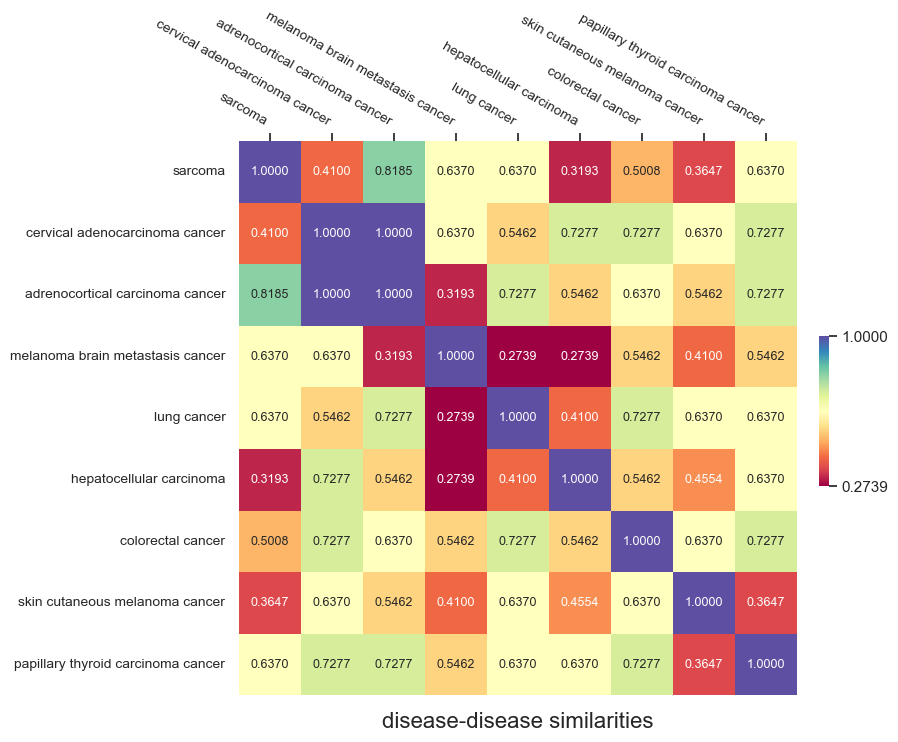

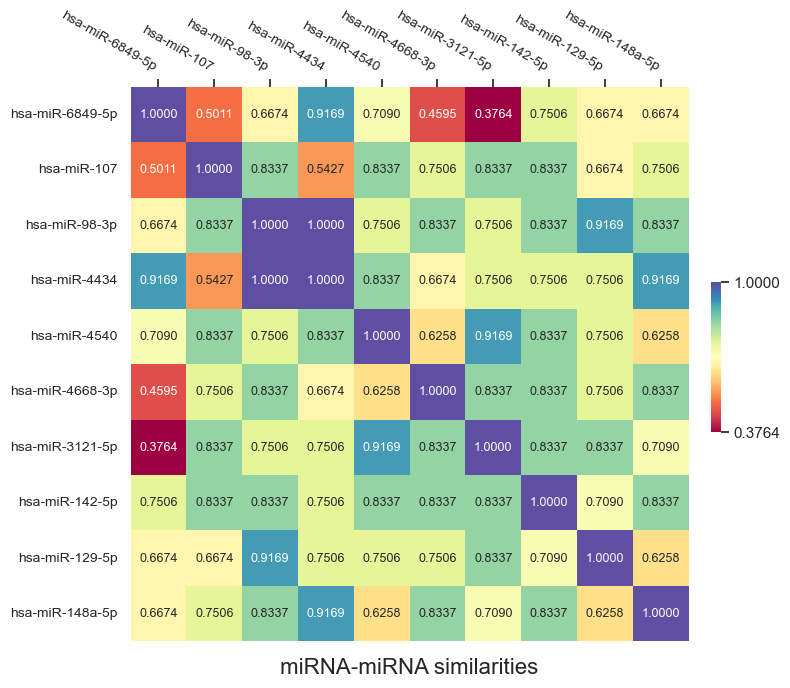

Cluster index 9 is out of bounds for miRNA_list.

INITIAL EMBEDDING RESULTS
Initial miRNA Silhouette Score: 0.59803706407547
Initial miRNA Davies-Bouldin Index: 0.34727887824659937
Initial disease Silhouette Score: 0.5905835032463074
Initial disease Davies-Bouldin Index: 0.39030139714453677



Training:  20%|██        | 2/10 [00:00<00:01,  4.03epoch/s]

Best F1 Score: 0.522303664921466
Epoch 1 - F1 Train: 0.14820435002529084, F1 Valid: 0.522303664921466, Accuracy Train: 0.08278867102396514, Accuracy Valid: 0.3551031947978513
Best F1 Score: 0.8766687857596949
Epoch 2 - F1 Train: 0.30833141010846987, F1 Valid: 0.8766687857596949, Accuracy Train: 0.18382352941176472, Accuracy Valid: 0.7806050325134295


Training:  40%|████      | 4/10 [00:00<00:01,  5.40epoch/s]

Best F1 Score: 0.9840540152276972
Epoch 3 - F1 Train: 0.5714842228282041, F1 Valid: 0.9840540152276972, Accuracy Train: 0.4008714596949891, Accuracy Valid: 0.9686174724342663
Best F1 Score: 0.9978750531236719
Epoch 4 - F1 Train: 0.8706352868789416, F1 Valid: 0.9978750531236719, Accuracy Train: 0.7709694989106753, Accuracy Valid: 0.9957591178965225


...

Best F1 Score: 0.9980169971671388
Epoch 5 - F1 Train: 0.9757254464285714, F1 Valid: 0.9980169971671388, Accuracy Train: 0.9526143790849673, Accuracy Valid: 0.9960418433700876
Best F1 Score: 0.9980169971671388
Epoch 6 - F1 Train: 0.9978165938864629, F1 Valid: 0.9980169971671388, Accuracy Train: 0.9956427015250545, Accuracy Valid: 0.9960418433700876


Training:  80%|████████  | 8/10 [00:01<00:00,  5.97epoch/s]

Best F1 Score: 0.9980169971671388
Epoch 7 - F1 Train: 0.9984999318150825, F1 Valid: 0.9980169971671388, Accuracy Train: 0.9970043572984749, Accuracy Valid: 0.9960418433700876
Best F1 Score: 0.9980169971671388
Epoch 8 - F1 Train: 0.9984999318150825, F1 Valid: 0.9980169971671388, Accuracy Train: 0.9970043572984749, Accuracy Valid: 0.9960418433700876


Best F1 Score: 0.9980169971671388
Epoch 9 - F1 Train: 0.9984999318150825, F1 Valid: 0.9980169971671388, Accuracy Train: 0.9970043572984749, Accuracy Valid: 0.9960418433700876
Best F1 Score: 0.9980169971671388
Epoch 10 - F1 Train: 0.9984999318150825, F1 Valid: 0.9980169971671388, Accuracy Train: 0.9970043572984749, Accuracy Valid: 0.9960418433700876
Available node attributes: dict_keys(['weight', 'significance', 'node_type'])
node_types_-----------------------------
 tensor([1, 1, 1,  ..., 1, 1, 1])
miRNA mask size: 3489, Disease mask size: 183


FINAL node_types ===================== [1 1 1 ... 1 1 1]
FINAL miRNA embedding shape: (3489, 128)
FINAL disease embedding shape: (183, 128)
FINAL miRNA cluster labels: 3489
FINAL miRNA nodes: 3489
FINAL disease cluster labels: 183
FINAL disease nodes: 183
FINAL miRNA list: ['hsa-miR-6849-5p', 'hsa-miR-107', 'hsa-miR-566', 'hsa-miR-98-3p', 'hsa-miR-4434', 'hsa-miR-4540', 'hsa-miR-3121-5p', 'hsa-miR-142-5p', 'hsa-miR-129-5p', 'hsa-miR-148a-5p']
FINAL disease list: ['sarcoma', 'cervical adenocarcinoma cancer', 'adrenocortical carcinoma cancer', 'melanoma brain metastasis cancer', 'glioma cancer', 'lung cancer', 'colorectal cancer', 'wilms tumor cancer', 'skin cutaneous melanoma cancer', 'papillary thyroid carcinoma cancer']


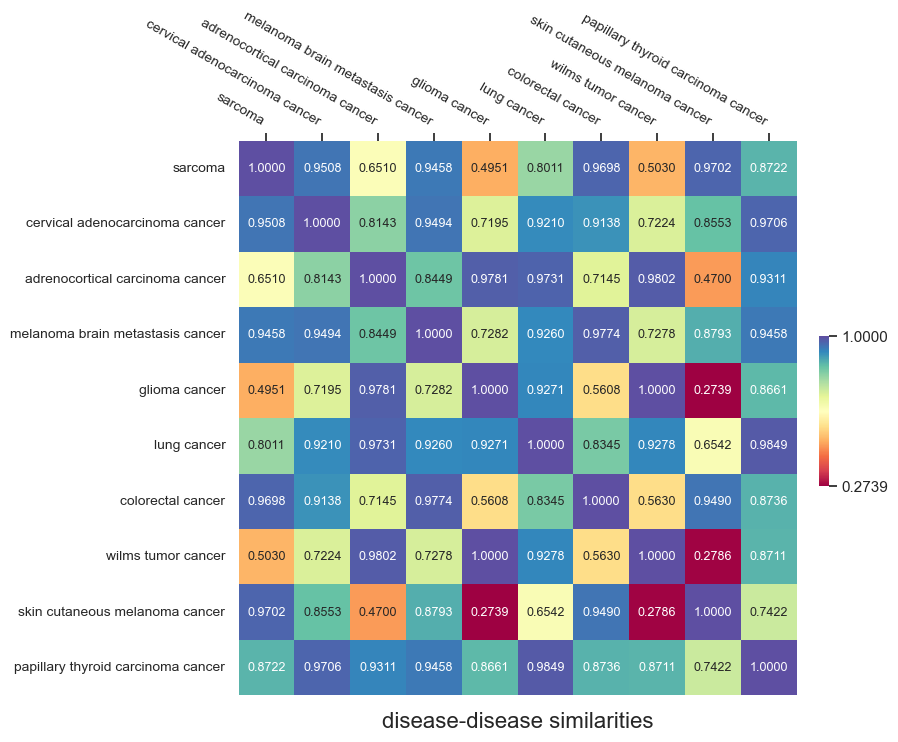

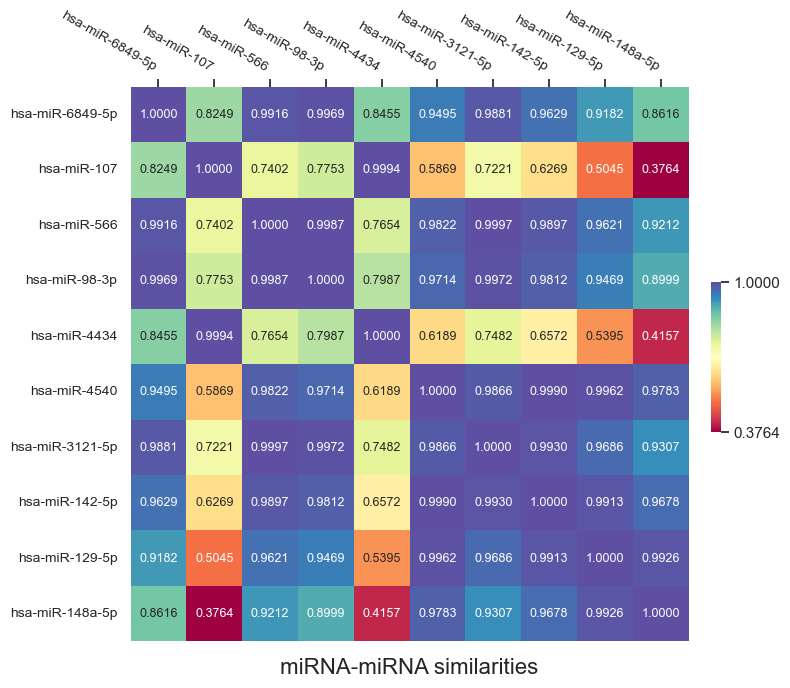



INITIAL vs FINAL EMBEDDING RESULTS

miRNA:
  INITIAL Silhouette Score: 0.598037
  FINAL   Silhouette Score: 0.600137
  Change  Silhouette Score: +0.002100
  INITIAL Davies-Bouldin: 0.347279
  FINAL   Davies-Bouldin: 0.358069
  Change  Davies-Bouldin: +0.010790

Disease:
  INITIAL Silhouette Score: 0.590584
  FINAL   Silhouette Score: 0.569971
  Change  Silhouette Score: -0.020613
  INITIAL Davies-Bouldin: 0.390301
  FINAL   Davies-Bouldin: 0.472887
  Change  Davies-Bouldin: +0.082585
Model saved to: data/emb/models/model_dim128_lay2_epo10.pth


In [141]:
model_path = train(hyperparams=hyperparams, data_path=data_path, plot=plot)
print(f'Model saved to: {model_path}')